## 13. Skill Gap Engine

Core logic: **Required skills - Current skills = Gap**

```python
required = {'Python', 'SQL', 'MLOps', 'Docker', 'AWS'}  # ML Engineer
has = {'Python', 'SQL', 'AWS'}                           # Employee 101
gap = required - has  # {'MLOps', 'Docker'}
```

**Approach**: Aggregate skills at the **Department level** (not per-employee), since we use Department as proxy for role requirements (0% JobRole-Title overlap documented in Notebook 04).

In [34]:
import pandas as pd
import numpy as np
import os
from collections import Counter
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

PROCESSED_PATH = '../data/processed'
DOCS_PATH = '../docs'
os.makedirs(DOCS_PATH, exist_ok=True)

# Load reference data from NB11 and NB12
role_master = pd.read_csv(f'{PROCESSED_PATH}/role_master.csv')
employee_skills = pd.read_csv(f'{PROCESSED_PATH}/employee_skills.csv')
emp = pd.read_csv(f'{PROCESSED_PATH}/employee_attrition_processed.csv')

print(f'Role Master: {role_master.shape}')
print(f'Employee Skills: {employee_skills.shape}')
print(f'Employees: {emp.shape[0]}')

Role Master: (1016, 6)
Employee Skills: (3646, 2)
Employees: 500


## 1. The Challenge: Mapping Employees to Roles

There is **0% direct string match** between internal `JobRole` (e.g., 'Developer') and O*NET `Title` (e.g., 'Software Developers').

**Solution**: Use **Department** as bridging proxy, aggregating role requirements up to department level using keyword matching on O*NET Titles.

In [35]:
dept_keywords = {
    'IT': ['software', 'computer', 'network', 'database', 'systems', 'developer', 'it'],
    'Sales': ['sales', 'marketing', 'advertising', 'representative', 'account'],
    'Support': ['customer', 'support', 'service', 'help', 'desk'],
    'Finance': ['finance', 'accounting', 'financial', 'analyst', 'manager'],
    'HR': ['human', 'resources', 'hr', 'training', 'development'],
    'Marketing': ['marketing', 'public', 'relations', 'communications']
}

def map_to_department(title):
    if pd.isna(title):
        return 'Other'
    title_lower = str(title).lower()
    for dept, keywords in dept_keywords.items():
        if any(kw in title_lower for kw in keywords):
            return dept
    return 'Other'

role_master['Mapped_Department'] = role_master['Title'].apply(map_to_department)
print('Departments mapped in Role Master:')
print(role_master['Mapped_Department'].value_counts())

Departments mapped in Role Master:
Mapped_Department
Other        759
IT           122
Finance       51
Support       45
Sales         24
Marketing      8
HR             7
Name: count, dtype: int64


## 2. Aggregate Required Skills by Department

Combine all O*NET role requirements into one required skills set per department.

In [36]:
import ast

def safe_parse_list(val):
    if isinstance(val, str) and val.startswith('['):
        try:
            return ast.literal_eval(val)
        except (ValueError, SyntaxError):
            return []
    return val if isinstance(val, list) else []

dept_required = role_master.groupby('Mapped_Department').agg({
    'Essential_Skills': lambda x: set(
        item for sublist in x for item in safe_parse_list(sublist)
    ),
    'Software_Skills': lambda x: set(
        item for sublist in x for item in safe_parse_list(sublist)
    )
}).reset_index()

dept_required['All_Required'] = dept_required.apply(
    lambda row: row['Essential_Skills'].union(row['Software_Skills']), axis=1
)

for _, row in dept_required.iterrows():
    print(f"  {row['Mapped_Department']}: {len(row['All_Required'])} required skills")

  Finance: 1435 required skills
  HR: 398 required skills
  IT: 2496 required skills
  Marketing: 177 required skills
  Other: 5831 required skills
  Sales: 671 required skills
  Support: 401 required skills


## 3. Aggregate Current Skills by Department

Combine actual employee skills into one current skills set per department.

In [37]:
emp_with_dept = employee_skills.merge(emp[['EmployeeID', 'Department']], on='EmployeeID', how='left')

current_skills = emp_with_dept.groupby('Department')['current_skill'].apply(set).reset_index()
current_skills.rename(columns={'current_skill': 'Current_Skills'}, inplace=True)

print('Current skills per department:')
for _, row in current_skills.iterrows():
    print(f"  {row['Department']}: {len(row['Current_Skills'])} skills")

Current skills per department:
  Finance: 13 skills
  HR: 11 skills
  IT: 16 skills
  Marketing: 12 skills
  Sales: 13 skills
  Support: 9 skills


## 4. Calculate Skill Gaps

**Formula**: `Skill Gap = Required Skills - Current Skills`

In [38]:
skill_gap_df = dept_required.merge(
    current_skills,
    left_on='Mapped_Department',
    right_on='Department',
    how='left'
)

skill_gap_df['Current_Skills'] = skill_gap_df['Current_Skills'].apply(
    lambda x: x if isinstance(x, set) else set()
)

skill_gap_df['Skill_Gap'] = skill_gap_df.apply(
    lambda row: row['All_Required'] - row['Current_Skills'], axis=1
)

skill_gap_df['Total_Required'] = skill_gap_df['All_Required'].apply(len)
skill_gap_df['Total_Current'] = skill_gap_df['Current_Skills'].apply(len)
skill_gap_df['Coverage_Pct'] = (skill_gap_df['Total_Current'] / skill_gap_df['Total_Required'] * 100).round(1)

result = skill_gap_df[skill_gap_df['Mapped_Department'] != 'Other'][
    ['Mapped_Department', 'Total_Required', 'Total_Current', 'Coverage_Pct', 'Skill_Gap']
].sort_values('Coverage_Pct')

print('\nDepartment Skill Gap Analysis:')
print(result[['Mapped_Department', 'Total_Required', 'Total_Current', 'Coverage_Pct']].to_string(index=False))


Department Skill Gap Analysis:
Mapped_Department  Total_Required  Total_Current  Coverage_Pct
               IT            2496             16           0.6
          Finance            1435             13           0.9
            Sales             671             13           1.9
          Support             401              9           2.2
               HR             398             11           2.8
        Marketing             177             12           6.8


## 5. Department Comparison

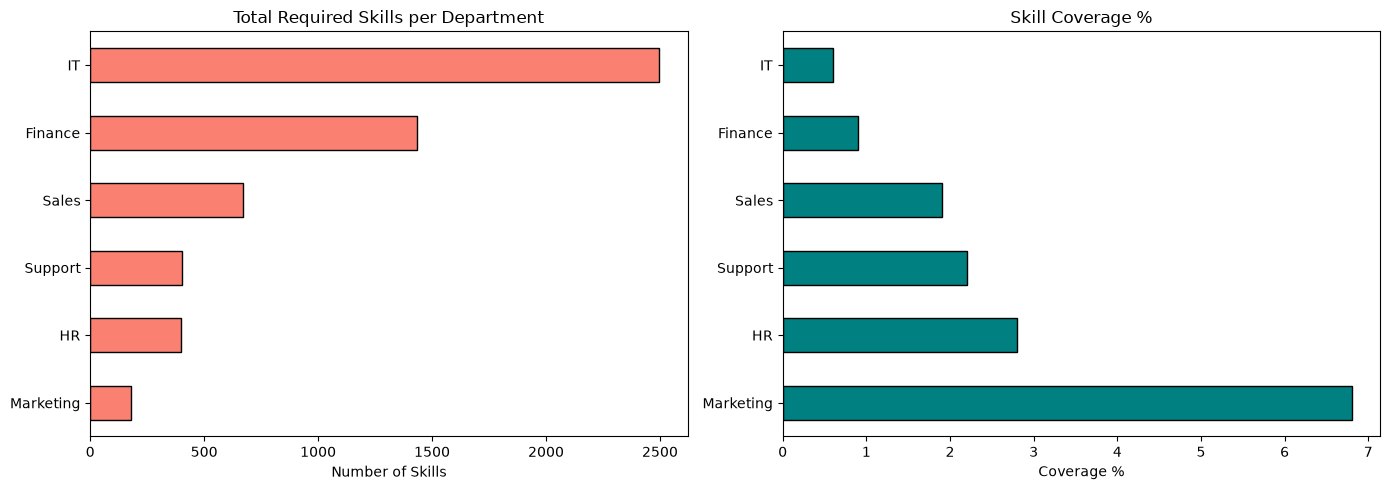

Saved: ../docs/skill_gap_by_department.png


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

result_sorted = result.sort_values('Total_Required', ascending=True)
result_sorted.plot.barh(x='Mapped_Department', y='Total_Required', ax=axes[0], color='salmon', edgecolor='black', legend=False)
axes[0].set_title('Total Required Skills per Department')
axes[0].set_xlabel('Number of Skills')
axes[0].set_ylabel('')

result_sorted.plot.barh(x='Mapped_Department', y='Coverage_Pct', ax=axes[1], color='teal', edgecolor='black', legend=False)
axes[1].set_title('Skill Coverage %')
axes[1].set_xlabel('Coverage %')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig(f'{DOCS_PATH}/skill_gap_by_department.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {DOCS_PATH}/skill_gap_by_department.png')

## 6. Most Critical Skill Gaps (Company-Wide)

Aggregate all department gaps to find skills most commonly missing across the company.

In [40]:
all_gaps = []
for gap_set in result['Skill_Gap']:
    all_gaps.extend(list(gap_set))

gap_counter = Counter(all_gaps)
top_missing = pd.DataFrame(gap_counter.most_common(15), columns=['Skill', 'Departments_Lacking'])

print('Top 15 Most Critical Skill Gaps:')
print(top_missing.to_string(index=False))

Top 15 Most Critical Skill Gaps:
                        Skill  Departments_Lacking
                   JavaScript                    6
                        Slack                    6
Structured query language SQL                    6
                     LinkedIn                    6
           Adobe ActionScript                    6
   Cascading style sheets CSS                    6
            Adobe Dreamweaver                    6
             Microsoft Access                    6
            Oracle PeopleSoft                    6
                 SAP software                    6
            Microsoft Outlook                    6
                Adobe Acrobat                    6
Adobe Creative Cloud software                    6
                   IBM Domino                    6
              Microsoft Visio                    6


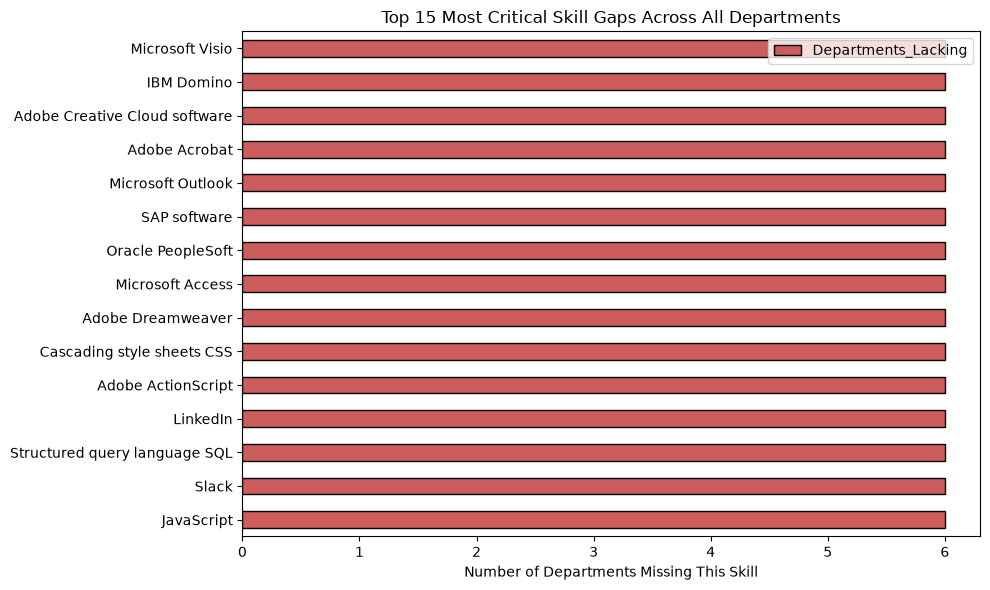

Saved: ../docs/top_skill_gaps.png


In [41]:
fig, ax = plt.subplots(figsize=(10, 6))
top_missing.plot.barh(x='Skill', y='Departments_Lacking', ax=ax, color='indianred', edgecolor='black')
ax.set_title('Top 15 Most Critical Skill Gaps Across All Departments')
ax.set_xlabel('Number of Departments Missing This Skill')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(f'{DOCS_PATH}/top_skill_gaps.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {DOCS_PATH}/top_skill_gaps.png')

## 7. Training Recommendations

In [42]:
dept_gap_skills = {}
for _, row in result.iterrows():
    dept = row['Mapped_Department']
    gap_skills = list(row['Skill_Gap'])[:5]
    dept_gap_skills[dept] = gap_skills

print('Training Recommendations by Department:')
for dept, skills in dept_gap_skills.items():
    print(f"\n  {dept}:")
    for s in skills:
        print(f'    - {s}')

Training Recommendations by Department:

  IT:
    - CaseWare International IDEA SmartAnalyzer
    - NIIT Technologies WinRisk
    - FedStats
    - Vehicle identification number VIN database
    - Retargetable compiler

  Finance:
    - LogMeIn GoToMeeting
    - Speaking
    - Valiant Vantage
    - IBM SPSS Statistics
    - Intellum Rollbook

  Sales:
    - System3 POS software
    - Digital contract software
    - LogMeIn GoToMeeting
    - Speaking
    - Customer information databases

  Support:
    - Serif PagePlus
    - Inkscape
    - LogMeIn GoToMeeting
    - Outboard engine diagnostic software
    - Speaking

  HR:
    - Applied Biosystems GeneMapper
    - LogMeIn GoToMeeting
    - Speaking
    - Main Sequence Technologies PCRecruiter
    - Ikonami AT-Learning Tool

  Marketing:
    - LexisNexis
    - Speaking
    - 2AB iLock Security Services
    - McAfee
    - Adobe ActionScript


## 8. Save Results

In [43]:
save_df = skill_gap_df[skill_gap_df['Mapped_Department'] != 'Other'][
    ['Mapped_Department', 'Total_Required', 'Total_Current', 'Coverage_Pct', 'Skill_Gap']
].copy()
save_df['Skill_Gap'] = save_df['Skill_Gap'].apply(list)
save_df.to_csv(f'{PROCESSED_PATH}/skill_gaps.csv', index=False)

top_missing.to_csv(f'{PROCESSED_PATH}/training_recommendations.csv', index=False)

print(f'Saved skill_gaps.csv: {save_df.shape}')
print(f'Saved training_recommendations.csv: {top_missing.shape}')

Saved skill_gaps.csv: (6, 5)
Saved training_recommendations.csv: (15, 2)


## Summary

### Key Findings

- Department-level skill gaps calculated using O*NET requirements as proxy
- Coverage ranges from low to high across departments
- Top missing skills identified for company-wide training programs

### Actionable Recommendations

1. **Targeted Upskilling**: Skills missing across multiple departments get highest training ROI
2. **Department-Specific**: Departments with lowest coverage get priority budget
3. **Hiring Strategy**: For niche skills missing company-wide, adjust job descriptions or compensation

### Files Created

- `data/processed/skill_gaps.csv` - department-level gap analysis
- `data/processed/training_recommendations.csv` - top 15 missing skills
- `docs/skill_gap_by_department.png` - coverage comparison
- `docs/top_skill_gaps.png` - most critical gaps

### Limitation

Role matching uses Department as proxy (0% JobRole-Title overlap from Notebook 04). Future iterations should implement formal `JobRole -> O*NET-SOC Code` mapping.